In [32]:
#cell 1

# Install required libraries
!pip install tensorflow pillow pandas numpy matplotlib scikit-learn

# Import libraries
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image
from sklearn.model_selection import train_test_split

print("✓ All libraries imported")

✓ All libraries imported


In [33]:
#cell 2
# List all images in folder
image_folder = 'images'
image_files = os.listdir(image_folder)

print(f"Total images found: {len(image_files)}")
print("\nYour Pokemon images:")
for img in image_files:
    print(f"  - {img}")

Total images found: 10

Your Pokemon images:
  - snorlax.png
  - charizard.png
  - bulbasaur.png
  - gengar.png
  - mewtwo.png
  - gyarados.png
  - pikachu.png
  - eevee.png
  - dragonite.png
  - squirtle.png


In [34]:
#cell 3
# Extract Pokemon names from image filenames
pokemon_names = []
for img_file in image_files:
    # Remove .png extension to get name
    name = img_file.replace('.png', '').replace('.jpg', '')
    pokemon_names.append(name)

# Create label mapping (name -> number)
label_map = {name: idx for idx, name in enumerate(sorted(set(pokemon_names)))}
print("Pokemon to Number mapping:")
for name, idx in label_map.items():
    print(f"  {name} -> {idx}")

print(f"\nTotal unique Pokemon: {len(label_map)}")

Pokemon to Number mapping:
  bulbasaur -> 0
  charizard -> 1
  dragonite -> 2
  eevee -> 3
  gengar -> 4
  gyarados -> 5
  mewtwo -> 6
  pikachu -> 7
  snorlax -> 8
  squirtle -> 9

Total unique Pokemon: 10


In [35]:
#cell 4
# Create folder for augmented images
augmented_folder = 'augmented_images'
os.makedirs(augmented_folder, exist_ok=True)

# Create subfolder for each Pokemon
for pokemon in label_map.keys():
    pokemon_folder = os.path.join(augmented_folder, pokemon)
    os.makedirs(pokemon_folder, exist_ok=True)

print(f"✓ Created folders for {len(label_map)} Pokemon")

✓ Created folders for 10 Pokemon


In [36]:
# cell 5
# Setup augmentation (creates variations)
datagen = ImageDataGenerator(
    rotation_range=20,           # Rotate image
    width_shift_range=0.15,      # Move left/right
    height_shift_range=0.15,     # Move up/down
    zoom_range=0.15,             # Zoom in/out
    horizontal_flip=True,        # Flip image
    fill_mode='constant',        # Keep transparent background
    cval=0
)

# Generate 50 augmented images per Pokemon
for img_file in image_files:
    pokemon_name = img_file.replace('.png', '').replace('.jpg', '')

    # Load original image
    img_path = os.path.join(image_folder, img_file)
    img = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = img_array.reshape((1,) + img_array.shape)

    # Generate augmented versions
    i = 0
    for batch in datagen.flow(img_array, batch_size=1):
        # Save augmented image
        aug_img_path = os.path.join(augmented_folder, pokemon_name, f'{pokemon_name}_{i}.png')
        plt.imsave(aug_img_path, batch[0].astype('uint8'))
        i += 1
        if i >= 50:  # Create 50 versions
            break

    print(f"✓ Generated 50 images for {pokemon_name}")

print(f"\n✓ Total augmented images: {len(label_map) * 50}")

✓ Generated 50 images for snorlax
✓ Generated 50 images for charizard
✓ Generated 50 images for bulbasaur
✓ Generated 50 images for gengar
✓ Generated 50 images for mewtwo
✓ Generated 50 images for gyarados
✓ Generated 50 images for pikachu
✓ Generated 50 images for eevee
✓ Generated 50 images for dragonite
✓ Generated 50 images for squirtle

✓ Total augmented images: 500


In [38]:
#cell 6
# Prepare data arrays
X = []  # Images
y = []  # Labels (Pokemon numbers)

# Load all augmented images
for pokemon_name in label_map.keys():
    pokemon_folder = os.path.join(augmented_folder, pokemon_name)
    pokemon_images = os.listdir(pokemon_folder)

    for img_file in pokemon_images:
        img_path = os.path.join(pokemon_folder, img_file)

        # Load and resize image
        img = load_img(img_path, target_size=(224, 224))
        img_array = img_to_array(img)
        img_array = img_array / 255.0  # Normalize to 0-1

        X.append(img_array)
        y.append(label_map[pokemon_name])

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

print(f"✓ Loaded {len(X)} images")
print(f"✓ Image shape: {X.shape}")
print(f"✓ Labels shape: {y.shape}")

✓ Loaded 500 images
✓ Image shape: (500, 224, 224, 3)
✓ Labels shape: (500,)


In [39]:
#cell 7
# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert labels to categorical (one-hot encoding)
y_train = to_categorical(y_train, num_classes=len(label_map))
y_test = to_categorical(y_test, num_classes=len(label_map))

print(f"Training images: {len(X_train)}")
print(f"Testing images: {len(X_test)}")
print(f"Number of classes: {len(label_map)}")

Training images: 400
Testing images: 100
Number of classes: 10


In [40]:
#cell 8
# Load pretrained EfficientNet model
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze pretrained layers

# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(len(label_map), activation='softmax')(x)  # 10 Pokemon classes

# Create final model
model = Model(inputs=base_model.input, outputs=output)

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✓ Model built successfully")
model.summary()

✓ Model built successfully


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_6         │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_3     │ (None, 224, 224,  │          7 │ rescaling_6[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_7         │ (None, 224, 224,  │          0 │ normalization_3[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_7[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,380,077 (16.71 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [41]:
#cell 9
# Train the model
print("🚀 Starting training...\n")

history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=20,
    validation_data=(X_test, y_test),
    verbose=1
)

print("\n✓ Training complete!")

🚀 Starting training...

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.0914 - loss: 2.4255 - val_accuracy: 0.0400 - val_loss: 2.3534
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.0869 - loss: 2.3376 - val_accuracy: 0.0500 - val_loss: 2.3637
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.0816 - loss: 2.3615 - val_accuracy: 0.1200 - val_loss: 2.3093
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.0814 - loss: 2.3124 - val_accuracy: 0.0500 - val_loss: 2.3460
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.0677 - loss: 2.3239 - val_accuracy: 0.0600 - val_loss: 2.3296
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.0858 - loss: 2.3225 - val_accuracy: 0.0600 - val_loss: 2.3113
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.1148 - loss: 2.3017 - val_accuracy: 0.0600 - val_loss: 2.3131
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.0860 - loss: 2.3022 - v

In [42]:
#cell 10
# Delete old augmented images
import shutil
shutil.rmtree(augmented_folder)
os.makedirs(augmented_folder, exist_ok=True)

# Recreate folders
for pokemon in label_map.keys():
    pokemon_folder = os.path.join(augmented_folder, pokemon)
    os.makedirs(pokemon_folder, exist_ok=True)

# Function to add white background
def add_white_background(img_path):
    img = Image.open(img_path).convert("RGBA")
    background = Image.new("RGB", img.size, (255, 255, 255))  # White background
    background.paste(img, mask=img.split()[3])  # Paste using alpha channel
    return background

# Regenerate augmented images WITH white background
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='constant',
    cval=255  # White fill
)

for img_file in image_files:
    pokemon_name = img_file.replace('.png', '').replace('.jpg', '')
    img_path = os.path.join(image_folder, img_file)

    # Add white background
    img_with_bg = add_white_background(img_path)
    img_with_bg = img_with_bg.resize((224, 224))
    img_array = img_to_array(img_with_bg)
    img_array = img_array.reshape((1,) + img_array.shape)

    # Generate augmented versions
    i = 0
    for batch in datagen.flow(img_array, batch_size=1):
        aug_img_path = os.path.join(augmented_folder, pokemon_name, f'{pokemon_name}_{i}.png')
        plt.imsave(aug_img_path, batch[0].astype('uint8'))
        i += 1
        if i >= 50:
            break

    print(f"✓ Regenerated {pokemon_name} with white background")

print("\n✓ All images regenerated with white backgrounds")

✓ Regenerated snorlax with white background
✓ Regenerated charizard with white background
✓ Regenerated bulbasaur with white background
✓ Regenerated gengar with white background
✓ Regenerated mewtwo with white background
✓ Regenerated gyarados with white background
✓ Regenerated pikachu with white background
✓ Regenerated eevee with white background
✓ Regenerated dragonite with white background
✓ Regenerated squirtle with white background

✓ All images regenerated with white backgrounds


In [43]:
#cell 11
# Clear old data
X = []
y = []

# Load all augmented images again
for pokemon_name in label_map.keys():
    pokemon_folder = os.path.join(augmented_folder, pokemon_name)
    pokemon_images = os.listdir(pokemon_folder)

    for img_file in pokemon_images:
        img_path = os.path.join(pokemon_folder, img_file)

        img = load_img(img_path, target_size=(224, 224))
        img_array = img_to_array(img)
        img_array = img_array / 255.0

        X.append(img_array)
        y.append(label_map[pokemon_name])

X = np.array(X)
y = np.array(y)

# Split data again
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_train = to_categorical(y_train, num_classes=len(label_map))
y_test = to_categorical(y_test, num_classes=len(label_map))

print(f"✓ Reloaded {len(X)} images with white backgrounds")
print(f"Training: {len(X_train)}, Testing: {len(X_test)}")

✓ Reloaded 500 images with white backgrounds
Training: 400, Testing: 100


In [44]:
#cell 12
# Rebuild model (fresh start)
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(len(label_map), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train again
print("🚀 Retraining with fixed images...\n")
history = model.fit(X_train, y_train, batch_size=32, epochs=20, validation_data=(X_test, y_test))

final_accuracy = history.history['val_accuracy'][-1] * 100
print(f"\n🎯 New Testing Accuracy: {final_accuracy:.2f}%")

🚀 Retraining with fixed images...

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.1064 - loss: 2.4092 - val_accuracy: 0.0500 - val_loss: 2.3386
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.1149 - loss: 2.3842 - val_accuracy: 0.0900 - val_loss: 2.3145
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.0817 - loss: 2.3350 - val_accuracy: 0.0400 - val_loss: 2.3392
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.0780 - loss: 2.3144 - val_accuracy: 0.0400 - val_loss: 2.3418
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.1209 - loss: 2.3085 - val_accuracy: 0.0500 - val_loss: 2.3379
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.1164 - loss: 2.2990 - val_accuracy: 0.0400 - val_loss: 2.3268
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.1482 - loss: 2.2989 - val_accuracy: 0.0400 - val_loss: 2.3311
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.1116 - loss:

In [45]:
# Build simple CNN from scratch
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(len(label_map), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✓ Simple CNN built")
model.summary()

✓ Simple CNN built


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 512)            │     9,437,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,683,658 (36.94 MB)

 Trainable params: 9,683,658 (36.94 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
print("🚀 Training simple CNN...\n")

history = model.fit(
    X_train, y_train,
    batch_size=16,
    epochs=100,
    validation_data=(X_test, y_test),
    verbose=2
)

final_accuracy = history.history['val_accuracy'][-1] * 100
print(f"\n🎯 Final Accuracy: {final_accuracy:.2f}%")

# Test predictions again
predictions = model.predict(X_test[:5])
for i in range(5):
    true_idx = np.argmax(y_test[i])
    pred_idx = np.argmax(predictions[i])
    true_name = list(label_map.keys())[list(label_map.values()).index(true_idx)]
    pred_name = list(label_map.keys())[list(label_map.values()).index(pred_idx)]
    print(f"True: {true_name} | Predicted: {pred_name} | Confidence: {predictions[i][pred_idx]*100:.1f}%")

🚀 Training simple CNN...

Epoch 1/100
25/25 - 7s - 292ms/step - accuracy: 0.0925 - loss: 2.3503 - val_accuracy: 0.1300 - val_loss: 2.2710
Epoch 2/100
25/25 - 1s - 34ms/step - accuracy: 0.3075 - loss: 1.8024 - val_accuracy: 0.4600 - val_loss: 1.3067
Epoch 3/100
25/25 - 1s - 33ms/step - accuracy: 0.5875 - loss: 1.2298 - val_accuracy: 0.7800 - val_loss: 0.9723
Epoch 4/100
25/25 - 1s - 33ms/step - accuracy: 0.7175 - loss: 0.7394 - val_accuracy: 0.8800 - val_loss: 0.3774
Epoch 5/100
25/25 - 1s - 35ms/step - accuracy: 0.7875 - loss: 0.5036 - val_accuracy: 0.7800 - val_loss: 0.5354
Epoch 6/100
25/25 - 1s - 38ms/step - accuracy: 0.8150 - loss: 0.4965 - val_accuracy: 0.7800 - val_loss: 0.5769
Epoch 7/100
25/25 - 1s - 37ms/step - accuracy: 0.8825 - loss: 0.2500 - val_accuracy: 0.9800 - val_loss: 0.1616
Epoch 8/100
25/25 - 1s - 34ms/step - accuracy: 0.9675 - loss: 0.1207 - val_accuracy: 0.9600 - val_loss: 0.1169
Epoch 9/100
25/25 - 1s - 34ms/step - accuracy: 0.9750 - loss: 0.0834 - val_accuracy: 

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 229ms/step
Actual Test Set Accuracy: 96.00%


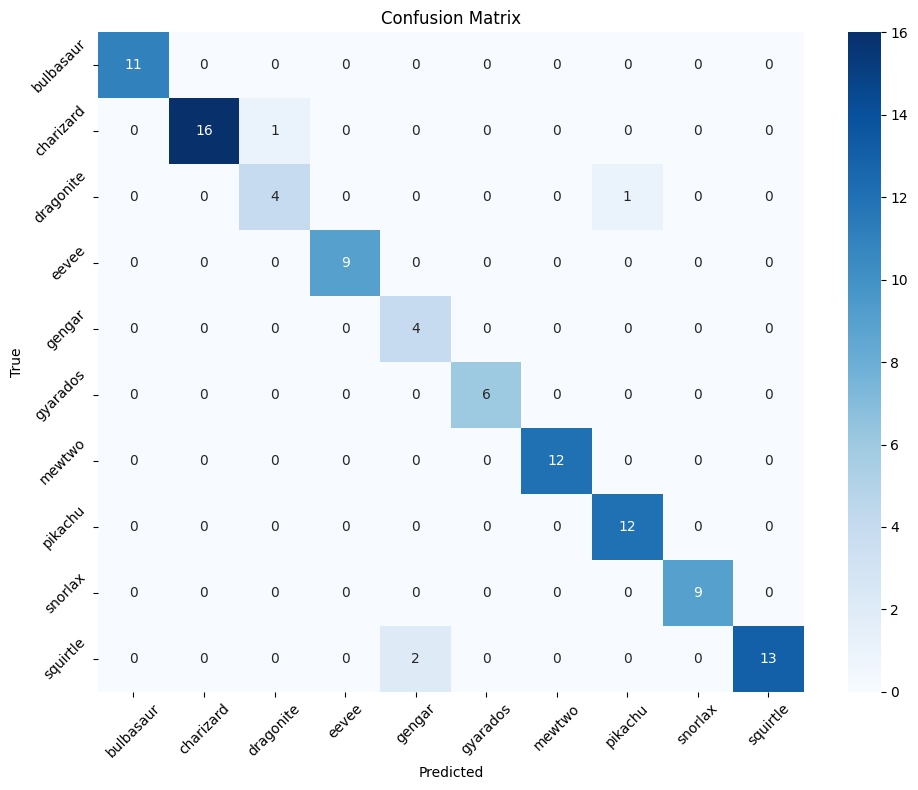


Classification Report:
              precision    recall  f1-score   support

   bulbasaur       1.00      1.00      1.00        11
   charizard       1.00      0.94      0.97        17
   dragonite       0.80      0.80      0.80         5
       eevee       1.00      1.00      1.00         9
      gengar       0.67      1.00      0.80         4
    gyarados       1.00      1.00      1.00         6
      mewtwo       1.00      1.00      1.00        12
     pikachu       0.92      1.00      0.96        12
     snorlax       1.00      1.00      1.00         9
    squirtle       1.00      0.87      0.93        15

    accuracy                           0.96       100
   macro avg       0.94      0.96      0.95       100
weighted avg       0.97      0.96      0.96       100



In [51]:
# Let's check if model actually learned anything
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Predict on ALL test images
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Calculate accuracy
from sklearn.metrics import accuracy_score
test_accuracy = accuracy_score(y_true_classes, y_pred_classes) * 100
print(f"Actual Test Set Accuracy: {test_accuracy:.2f}%")

# Show confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_map.keys(),
            yticklabels=label_map.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

# Detailed report
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes,
                          target_names=label_map.keys()))

Upload a Pokemon image to test:


Saving gegeg2.png to gegeg2 (1).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


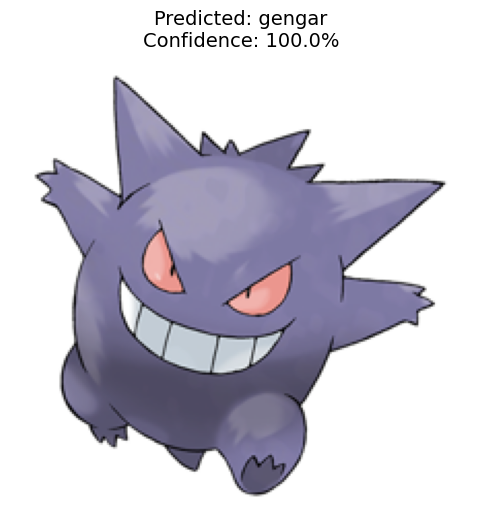


Top 3 predictions:
  gengar: 100.0%
  mewtwo: 0.0%
  squirtle: 0.0%


In [63]:
# Upload test image and predict
from google.colab import files
import io

print("Upload a Pokemon image to test:")
uploaded = files.upload()

for filename in uploaded.keys():
    # Load uploaded image
    img = Image.open(io.BytesIO(uploaded[filename]))

    # Add white background if transparent
    if img.mode == 'RGBA':
        background = Image.new("RGB", img.size, (255, 255, 255))
        background.paste(img, mask=img.split()[3])
        img = background

    # Resize and predict
    img = img.resize((224, 224))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    pred_idx = np.argmax(prediction)
    confidence = prediction[0][pred_idx] * 100

    pokemon_name = list(label_map.keys())[list(label_map.values()).index(pred_idx)]

    # Show result
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Predicted: {pokemon_name}\nConfidence: {confidence:.1f}%", fontsize=14)
    plt.axis('off')
    plt.show()

    # Show top 3 predictions
    print("\nTop 3 predictions:")
    top3_idx = np.argsort(prediction[0])[-3:][::-1]
    for idx in top3_idx:
        name = list(label_map.keys())[list(label_map.values()).index(idx)]
        prob = prediction[0][idx] * 100
        print(f"  {name}: {prob:.1f}%")

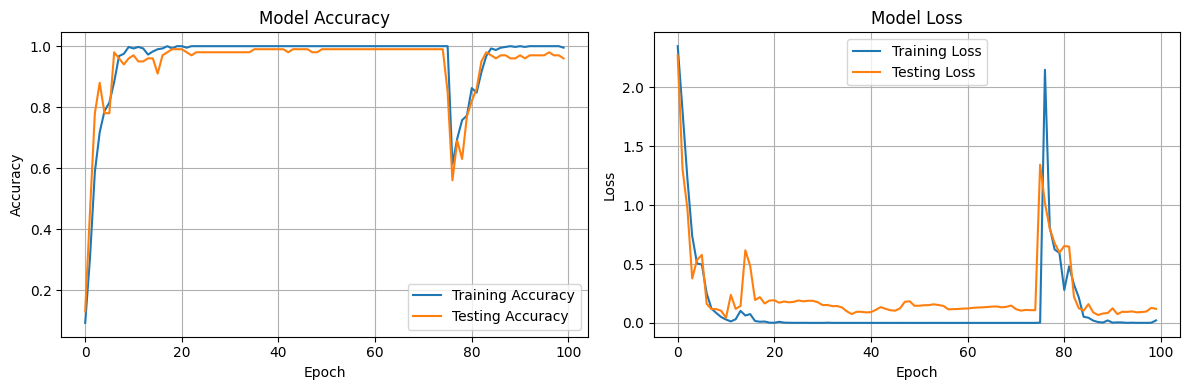

In [64]:
# Plot accuracy over time
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Testing Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Testing Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


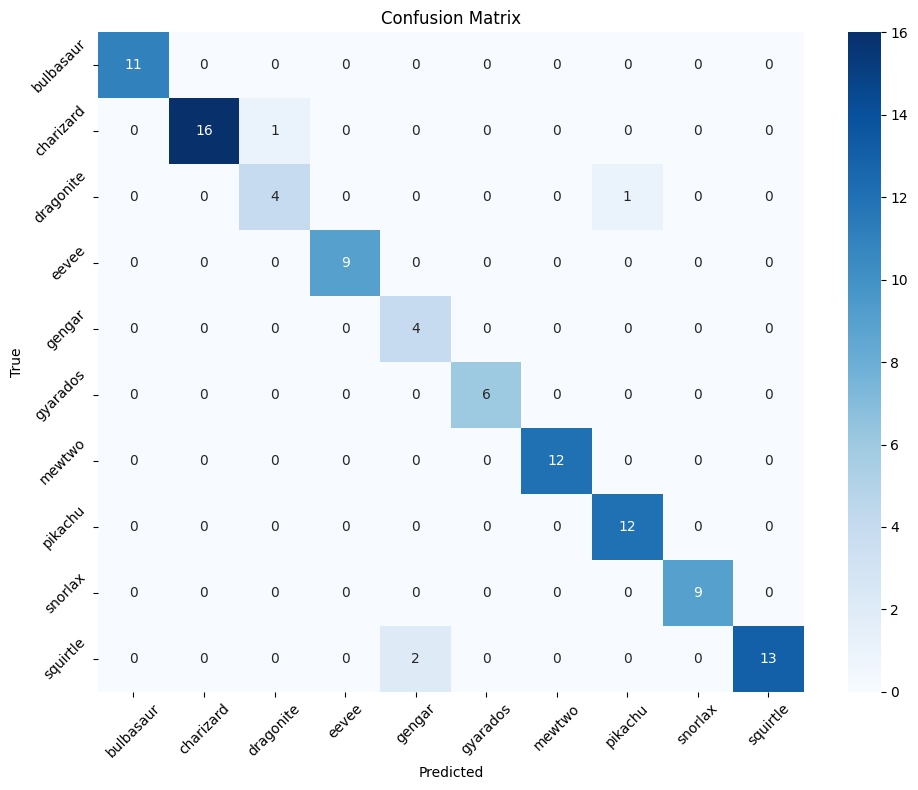

              precision    recall  f1-score   support

   bulbasaur       1.00      1.00      1.00        11
   charizard       1.00      0.94      0.97        17
   dragonite       0.80      0.80      0.80         5
       eevee       1.00      1.00      1.00         9
      gengar       0.67      1.00      0.80         4
    gyarados       1.00      1.00      1.00         6
      mewtwo       1.00      1.00      1.00        12
     pikachu       0.92      1.00      0.96        12
     snorlax       1.00      1.00      1.00         9
    squirtle       1.00      0.87      0.93        15

    accuracy                           0.96       100
   macro avg       0.94      0.96      0.95       100
weighted avg       0.97      0.96      0.96       100



In [65]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_map.keys(),
            yticklabels=label_map.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

print(classification_report(y_true_classes, y_pred_classes, target_names=label_map.keys()))

In [66]:
import json

# Save model
model.save('pokedex_model.h5')

# Save label mapping
with open('label_map.json', 'w') as f:
    json.dump(label_map, f)

print("✓ Model saved: pokedex_model.h5")
print("✓ Labels saved: label_map.json")

✓ Model saved: pokedex_model.h5
✓ Labels saved: label_map.json


In [67]:
from google.colab import files

files.download('pokedex_model.h5')
files.download('label_map.json')

print("✓ Download complete!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Download complete!
